In [1]:
from datasets import load_dataset

ds = load_dataset("imdb")

print(ds["train"][0])

c:\Users\Jomar\VSCode\ML\BasicML\ML\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [2]:
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from datasets import load_dataset
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
#load the dataset
dataset = load_dataset("imdb")
train_data = dataset["train"].shuffle(seed=42).select(range(2000))
test_data = dataset["test"].shuffle(seed=42).select(range(500))

In [5]:
#load the distilbert tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")


In [6]:
#tokenize the dataset
def tokenize_func(sample):
    return tokenizer(sample["text"], padding = "max_length", truncation = True, max_length = 128)

train_data = train_data.map(tokenize_func, batched = True)
test_data = test_data.map(tokenize_func, batched = True)

Map: 100%|██████████| 500/500 [00:00<00:00, 3102.72 examples/s]


In [7]:
#custom dataset class
class IMDBDataset(Dataset):
    def __init__(self, data):
        self.input_ids =data["input_ids"]
        self.attention_mask = data["attention_mask"]
        self.labels = data["label"]
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.input_ids[idx]),
            "attention_mask": torch.tensor(self.attention_mask[idx]),
            "labels": torch.tensor(self.labels[idx])
        }

In [8]:
#prepare the dataloaders
train_ds = IMDBDataset(train_data)
test_ds = IMDBDataset(test_data)

train_loader = DataLoader(train_ds, batch_size = 32, pin_memory= True)
test_loader = DataLoader(test_ds, batch_size = 16)

In [9]:
# Load model
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased")
model.to(device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [10]:
#init optim and loss
optimizer =  torch.optim.AdamW(model.parameters(), lr = 0.00005)
criterion = torch.nn.CrossEntropyLoss()

In [13]:
epochs = 20
train_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1} Loss: {avg_loss:.4f}")

    # Evaluation
    model.eval()
    preds, true = [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=1)

            preds.extend(predictions.cpu().numpy())
            true.extend(labels.cpu().numpy())

    acc = accuracy_score(true, preds)
    val_accuracies.append(acc)
    print(f"Validation Accuracy: {acc:.4f}")

Epoch 1: 100%|██████████| 63/63 [00:13<00:00,  4.82it/s]


Epoch 1 Loss: 0.0994
Validation Accuracy: 0.7940


Epoch 2: 100%|██████████| 63/63 [00:13<00:00,  4.72it/s]


Epoch 2 Loss: 0.0716
Validation Accuracy: 0.8180


Epoch 3: 100%|██████████| 63/63 [00:13<00:00,  4.61it/s]


...

Epoch 18 Loss: 0.0044
Validation Accuracy: 0.8100


Epoch 19: 100%|██████████| 63/63 [00:14<00:00,  4.34it/s]


Epoch 19 Loss: 0.0006
Validation Accuracy: 0.8240


Epoch 20: 100%|██████████| 63/63 [00:14<00:00,  4.35it/s]


Epoch 20 Loss: 0.0002
Validation Accuracy: 0.8280



 Classification Report
              precision    recall  f1-score   support

         Neg       0.83      0.84      0.83       254
         Pos       0.83      0.82      0.82       246

    accuracy                           0.83       500
   macro avg       0.83      0.83      0.83       500
weighted avg       0.83      0.83      0.83       500



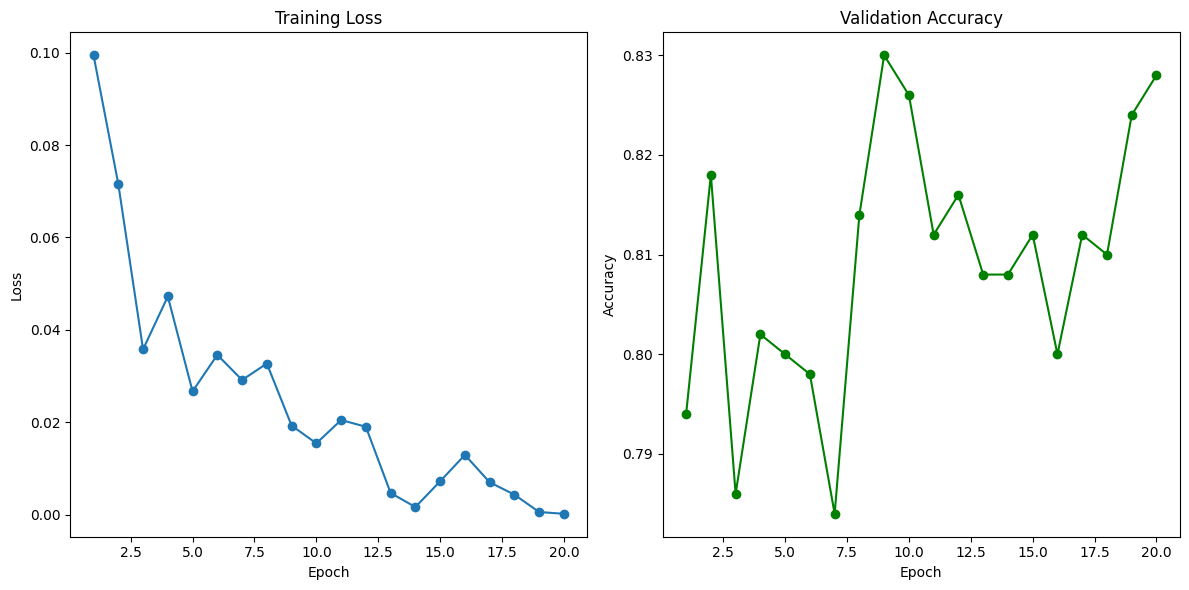

In [14]:
#Classification Report
print("\n Classification Report")
print(classification_report(true, preds, target_names = ["Neg", "Pos"]))
plt.figure(figsize = (12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), val_accuracies, marker='o', color='green')
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()